# Part attention, overlaid -- BPAM's own maps, and VAB's mixed output

Semi-transparent jet-colormap heatmaps overlaid directly on the photo (not flat side-by-side
panels) -- one section for BPAM's own raw per-branch attention (the pixel classifier's own
output), one section for what each branch looks like *after* VisualAttentionBlock mixes all M=1+K
branches together. Same technique as `init.ipynb`'s own VAB/TAB ablation cells, rebuilt against
the current CLIP-based encoder + the current VAB API (all M branches uniformly, not just the K
parts -- the old cells predate the branch-0-unification change and won't load against today's
`VisualAttentionBlock`/`PromptLearner`).

In [1]:
import os.path as osp
import random

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms as tv_transforms

from pcr import datasets
from pcr.models.clip_dense_part_encoder import CLIP_MEAN, CLIP_STD
from pcr.models.clip_rn50_bpam_encoder import ClipRN50BPAMEncoder
from pcr.models.clip_vit_bpam_encoder import ClipViTBPAMEncoder

HEIGHT, WIDTH = 384, 128
NUM_PARTS = 5
NUM_SAMPLES = 6
SEED = 7

VIT_CKPT = 'examples/logs/stage0_bpa_vit_b16/model_best.pth.tar'
RN50_CKPT = 'examples/logs/stage0_bpa_rn50/model_best.pth.tar'

if osp.isfile(VIT_CKPT):
    encoder = ClipViTBPAMEncoder(clip_arch='ViT-B/16', height=HEIGHT, width=WIDTH,
                                  num_parts=NUM_PARTS, checkpoint_path=VIT_CKPT, device='cuda').cuda()
    ARCH_NAME, CKPT_USED = 'ViT-B/16', VIT_CKPT
elif osp.isfile(RN50_CKPT):
    encoder = ClipRN50BPAMEncoder(clip_arch='RN50', height=HEIGHT, width=WIDTH,
                                   num_parts=NUM_PARTS, checkpoint_path=RN50_CKPT, device='cuda').cuda()
    ARCH_NAME, CKPT_USED = 'RN50', RN50_CKPT
else:
    raise FileNotFoundError("No Stage 0 checkpoint found -- run Stage 0 first.")

encoder.eval()
for p in encoder.parameters():
    p.requires_grad_(False)
print('Using {} checkpoint: {}'.format(ARCH_NAME, CKPT_USED))

Using RN50 checkpoint: examples/logs/stage0_bpa_rn50/model_best.pth.tar


In [2]:
dataset = datasets.create('market1501', osp.join('../datasets', 'market1501'))

random.seed(SEED)
samples = random.sample(dataset.train, NUM_SAMPLES)

normalizer = tv_transforms.Normalize(mean=list(CLIP_MEAN), std=list(CLIP_STD))
to_model = tv_transforms.Compose([
    tv_transforms.Resize((HEIGHT, WIDTH), interpolation=tv_transforms.InterpolationMode.BICUBIC),
    tv_transforms.ToTensor(),
    normalizer,
])

raw_images, model_inputs, pids = [], [], []
for fname, pid, camid in samples:
    fpath = fname if dataset.images_dir is None else osp.join(dataset.images_dir, fname)
    img = Image.open(fpath).convert('RGB')
    raw_images.append(np.array(img.resize((WIDTH, HEIGHT))))
    model_inputs.append(to_model(img))
    pids.append(pid)

batch = torch.stack(model_inputs, dim=0).cuda()

with torch.no_grad():
    f_out, vis, pixels_cls_scores = encoder.forward_full(batch)
    probs = F.softmax(pixels_cls_scores, dim=1)
    probs_up = F.interpolate(probs, size=(HEIGHT, WIDTH), mode='bilinear', align_corners=True)

# Reconstruct the exact M=1+K raw branch maps ClipBPAMEncoder._forward_common itself pools over --
# NOT the same as pixels_cls_scores' own raw channel order (channel 0 there is background, which
# is discarded; branch 0 of f_out is foreground = max over the K part probabilities at each
# pixel, per _forward_common's own `foreground_masks = parts_masks.amax(dim=-1)`).
parts_masks_up = probs_up[:, 1:]                        # [B, K, H, W]
foreground_map_up = parts_masks_up.amax(dim=1, keepdim=True)  # [B, 1, H, W]
branch_maps = torch.cat([foreground_map_up, parts_masks_up], dim=1).cpu().numpy()  # [B, M, H, W]

BRANCH_NAMES = ['foreground'] + ['part_{}'.format(k + 1) for k in range(NUM_PARTS)]
print('branch_maps shape:', branch_maps.shape, ' pids:', pids)

=> Market1501 loaded
Dataset statistics:
  ----------------------------------------
  subset   | # ids | # images | # cameras
  ----------------------------------------
  train    |   751 |    12936 |         6
  query    |   750 |     3368 |         6
  gallery  |   751 |    15913 |         6
  ----------------------------------------


branch_maps shape: (6, 6, 384, 128)  pids: [427, 476, 56, 327, 351, 342]


## BPAM's own raw attention, overlaid on the photo

One row per person, one column per branch -- `foreground` (max over all 5 parts) plus the 5 parts
themselves, each a semi-transparent jet heatmap directly on top of the image.

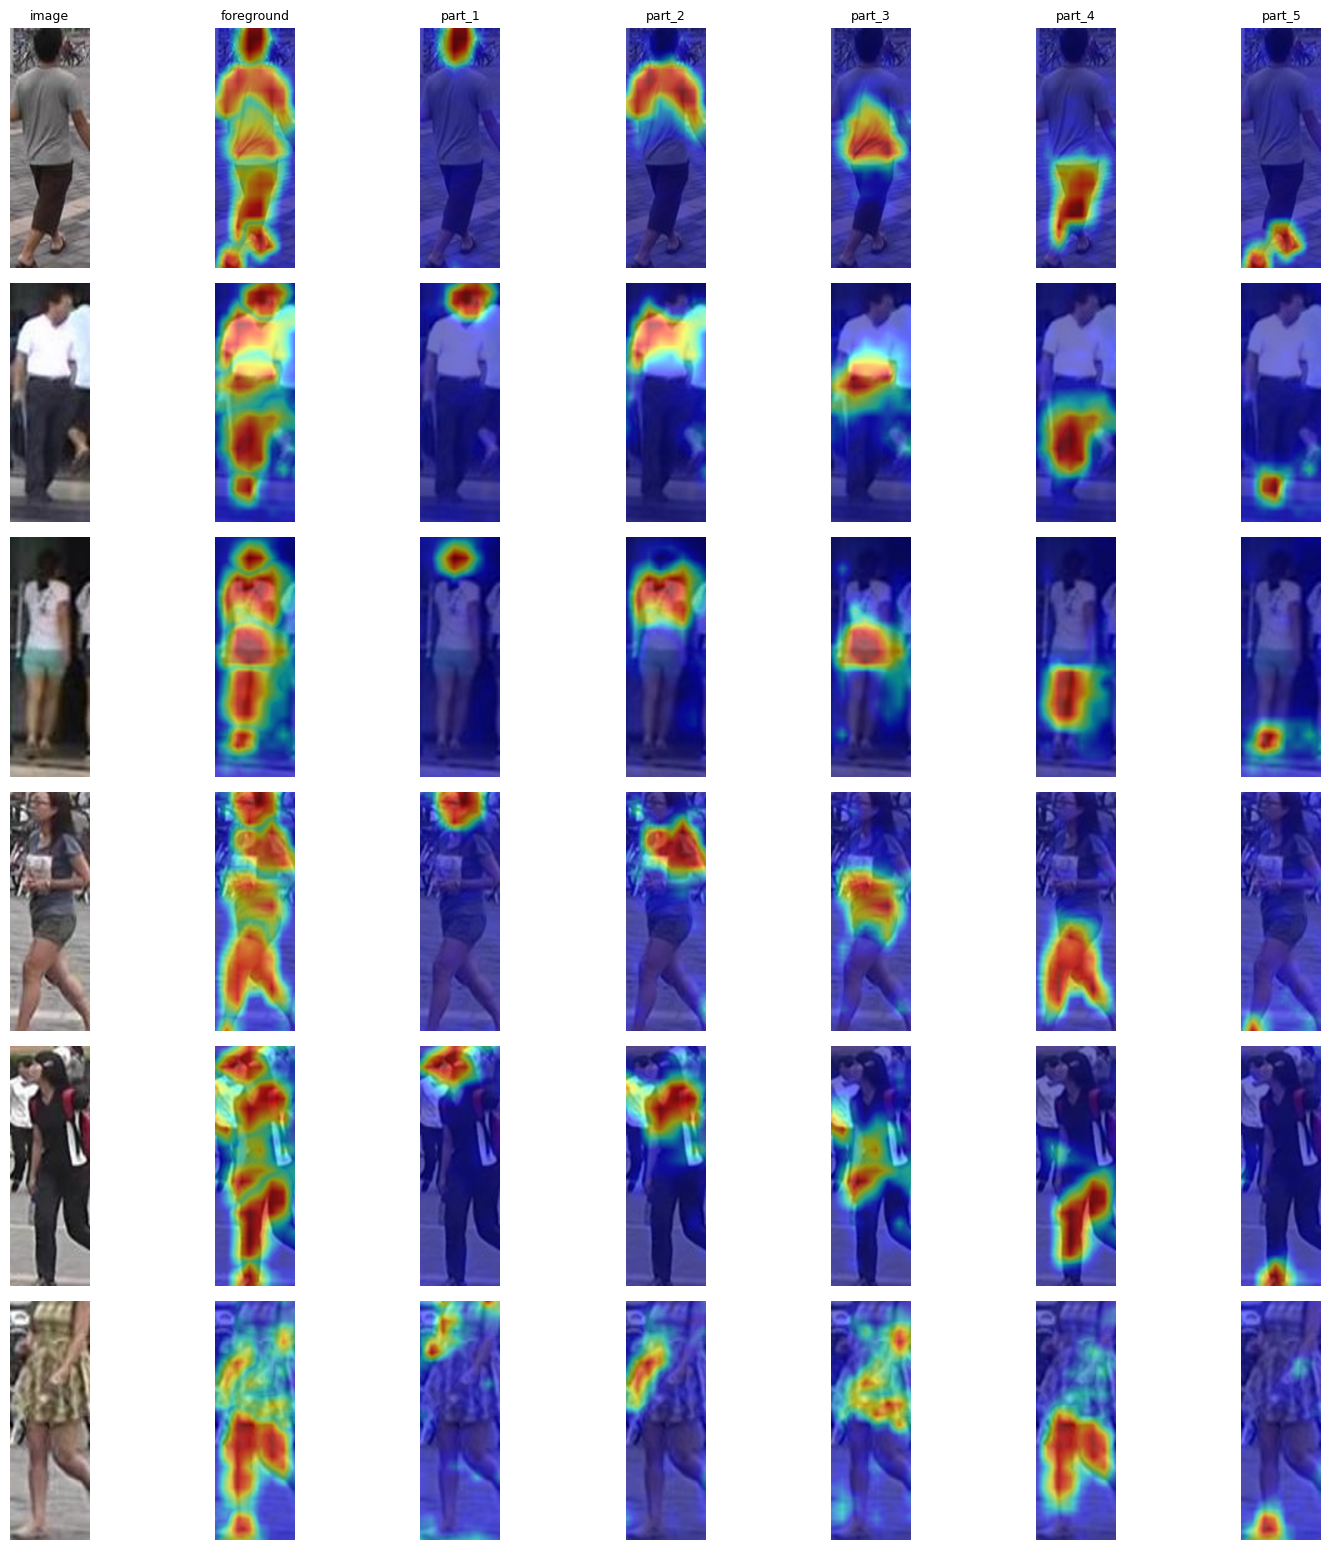

saved: examples/logs/part_mask_gallery/bpam_overlay.png


In [3]:
def overlay_grid(images, maps, branch_names, title_prefix=''):
    n_rows, n_cols = len(images), 1 + len(branch_names)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.2 * n_cols, 2.6 * n_rows))
    if n_rows == 1:
        axes = axes[None, :]
    for i in range(n_rows):
        axes[i, 0].imshow(images[i]); axes[i, 0].axis('off')
        axes[i, 0].set_title('image' if i == 0 else '', fontsize=9)
        for b, name in enumerate(branch_names):
            ax = axes[i, 1 + b]
            ax.imshow(images[i])
            m = maps[i, b]
            ax.imshow(m, cmap='jet', alpha=0.55, vmin=0, vmax=max(m.max(), 1e-8))
            if i == 0:
                ax.set_title('{}{}'.format(title_prefix, name), fontsize=9)
            ax.axis('off')
    plt.tight_layout()
    return fig

overlay_grid(raw_images, branch_maps, BRANCH_NAMES)
plt.savefig('examples/logs/part_mask_gallery/bpam_overlay.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved: examples/logs/part_mask_gallery/bpam_overlay.png')

## After VisualAttentionBlock -- each branch's mixed, relationally-attended output

Needs a real, trained `vab.pth` matching the *current* VAB API (all M=1+K branches uniformly) --
built by a real Stage 1 run against this same RN50 Stage 0 checkpoint
(`examples/logs/stage1_prompts_clip_rn50_viz/`, 25 epochs, not a 1-epoch smoke test). `vab(f_out,
vis)` already returns `(mixed, attn)` directly -- `attn` is `[B, M, M]`, no manual replay of
`nn.MultiheadAttention` needed the way the older ablation in `init.ipynb` had to do before this
class exposed its own attention pattern.

For output branch *i*, the image-space equivalent is `sum_j attn[i, j] * branch_maps[j]` --
literally which pixels actually fed into branch *i*'s representation once VAB's mixing is
accounted for.

In [4]:
from pcr.models.relation_blocks import VisualAttentionBlock
from pcr.utils.serialization import load_checkpoint

VAB_DIR = 'examples/logs/stage1_prompts_clip_rn50_viz'
VAB_DIM = 1024  # must match the RN50 Stage 1 run above's own dim_reduce_output

vab = VisualAttentionBlock(dim=VAB_DIM, num_heads=4, num_layers=1).cuda()
vab.load_state_dict(load_checkpoint(osp.join(VAB_DIR, 'vab.pth')))
vab.eval()

# f_out/vis here must come from the SAME dim_reduce_output as VAB_DIM -- if the encoder loaded
# above is ViT-B/16 (512-dim) instead of RN50 (1024-dim), this vab.pth won't load onto it; this
# section assumes the RN50 branch was taken above (true until a real ViT-B/16 Stage 0 checkpoint
# exists).
assert ARCH_NAME == 'RN50', "vab.pth above is RN50-dim (1024) -- rerun with an RN50 checkpoint, or train a matching ViT Stage 1 first."

with torch.no_grad():
    mixed, vab_attn = vab(f_out, vis)   # mixed: [B, M, D], vab_attn: [B, M, M]
vab_attn = vab_attn.cpu().numpy()

print('VAB attention, sample 0 (rows=output branch, cols=input branch, order = foreground, part_1..5):')
print(np.round(vab_attn[0], 3))
print('VAB gate (tanh):', torch.tanh(vab.gate).item())

=> Loaded checkpoint 'examples/logs/stage1_prompts_clip_rn50_viz/vab.pth'
VAB attention, sample 0 (rows=output branch, cols=input branch, order = foreground, part_1..5):
[[0.126 0.152 0.098 0.115 0.244 0.265]
 [0.124 0.145 0.096 0.111 0.248 0.277]
 [0.123 0.144 0.09  0.111 0.251 0.282]
 [0.125 0.146 0.092 0.114 0.255 0.268]
 [0.131 0.158 0.107 0.121 0.237 0.246]
 [0.134 0.169 0.118 0.124 0.22  0.236]]
VAB gate (tanh): 0.007394472602754831


/home/lakshh/workspace/reid/pcr2/pcr/models/relation_blocks.py:110: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


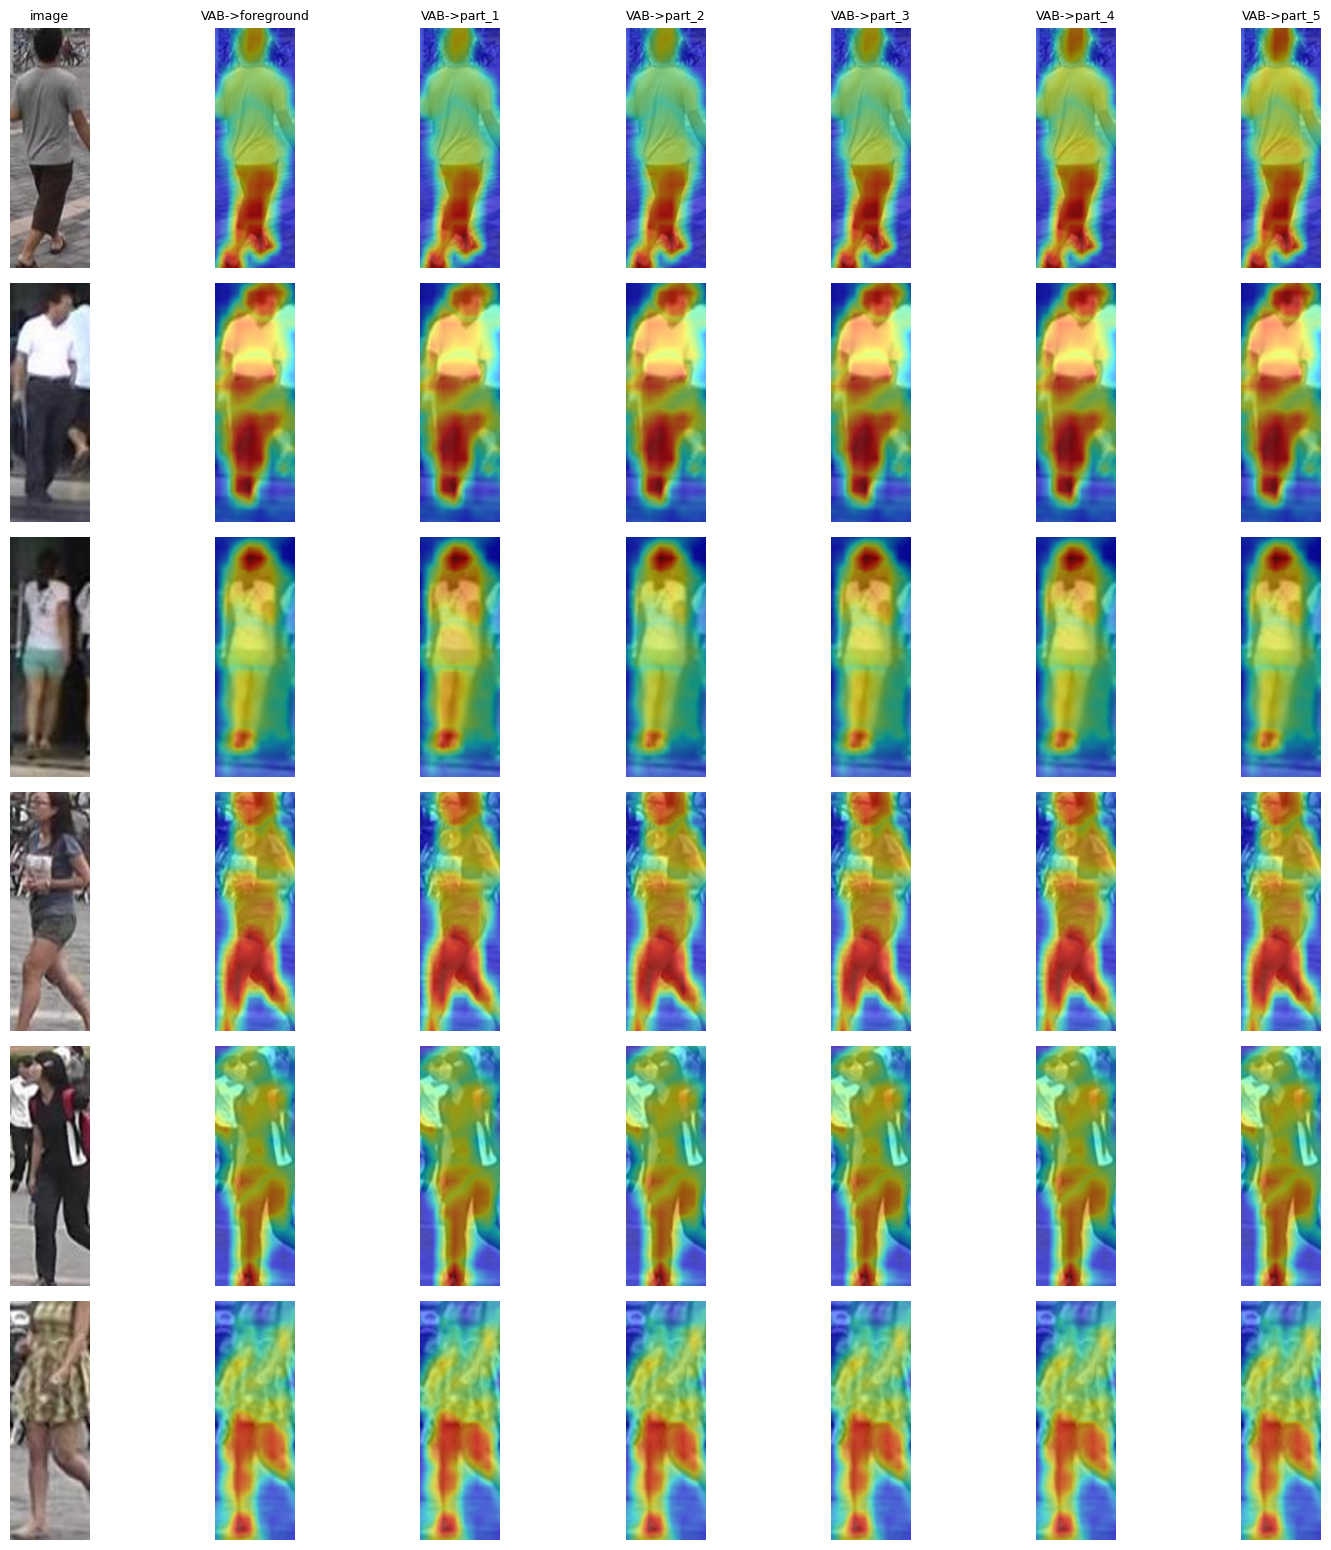

saved: examples/logs/part_mask_gallery/vab_overlay.png


In [5]:
vab_effective_maps = np.einsum('bij,bjhw->bihw', vab_attn, branch_maps)  # [B, M, H, W]

overlay_grid(raw_images, vab_effective_maps, ['VAB->' + n for n in BRANCH_NAMES])
plt.savefig('examples/logs/part_mask_gallery/vab_overlay.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved: examples/logs/part_mask_gallery/vab_overlay.png')